In [1]:
import sys
import os
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter


%matplotlib inline
np.random.seed(777)

# Load raw data 0016 (sequence number 04)

Data size: 271
Shape:
GPS: (271, 3)
VO: (271, 3)
IMU: (271, 6)
INS angle: (271, 3)
INS velocity: (271, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Data sampling is set to normal mode.


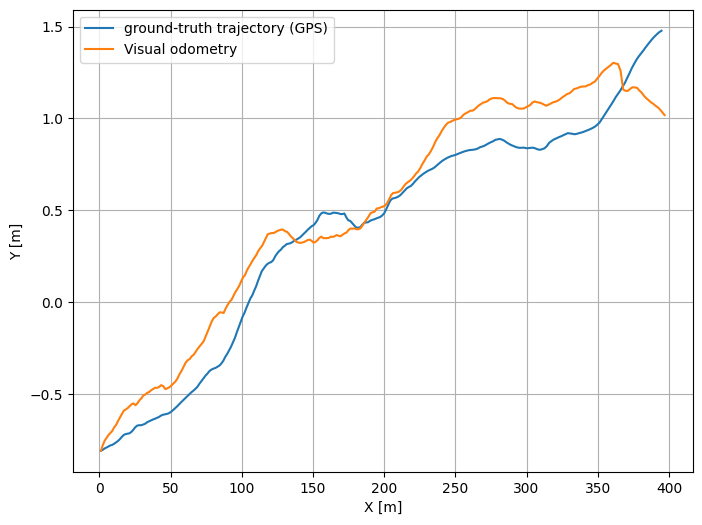

In [2]:
root_path = "../../"
file_export_path = os.path.join(root_path, "exports/_sequences/04")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0016'
noise_type = NoiseTypeEnum.CURRENT

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

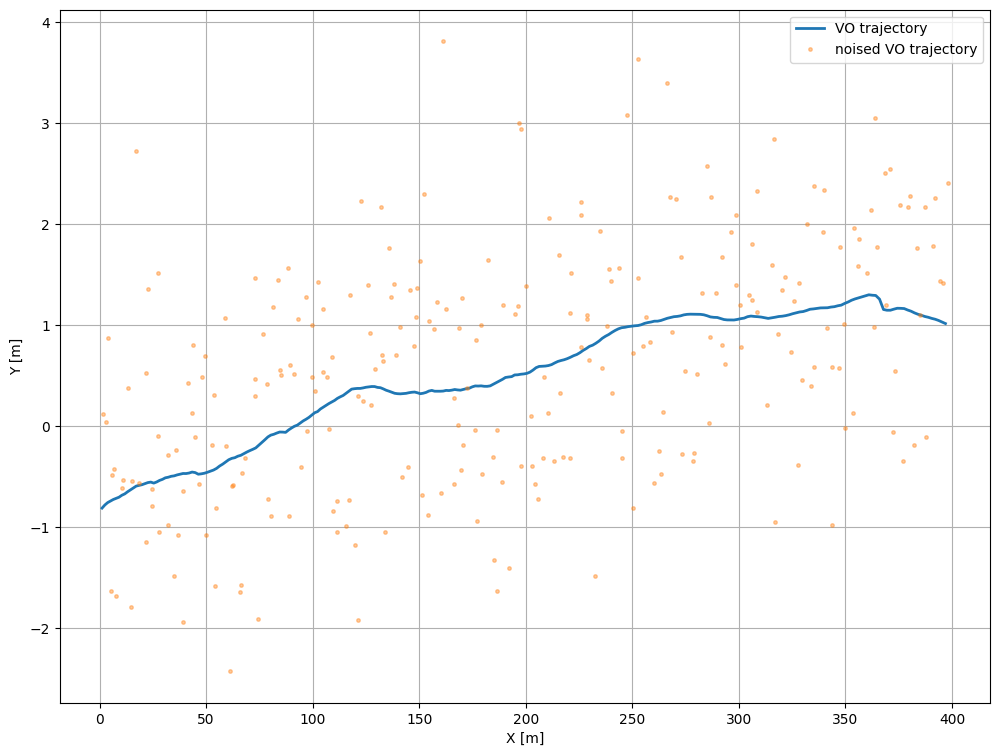

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

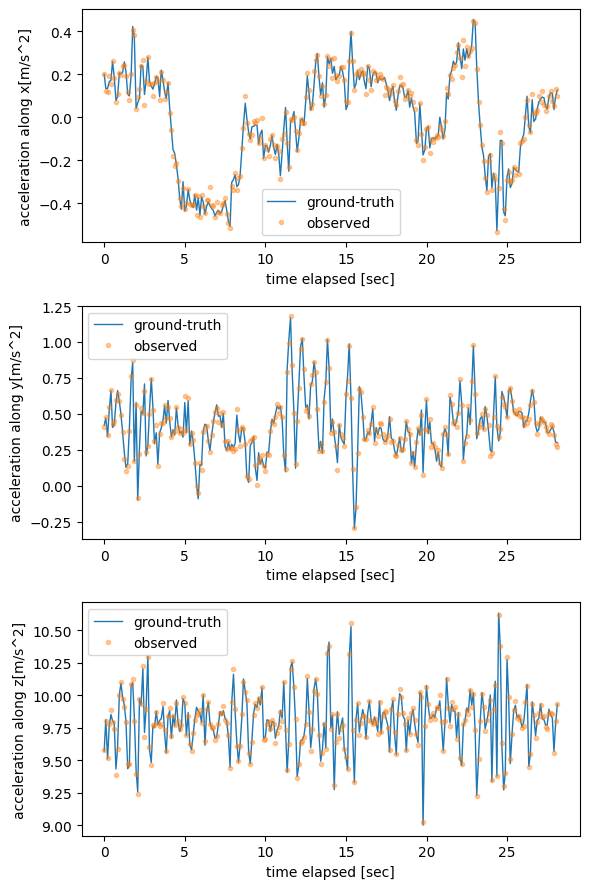

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

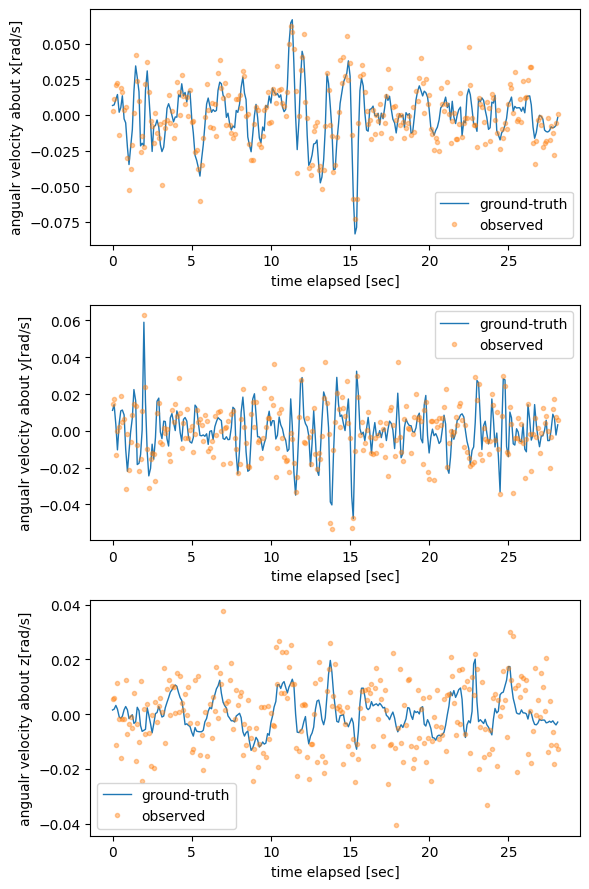

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

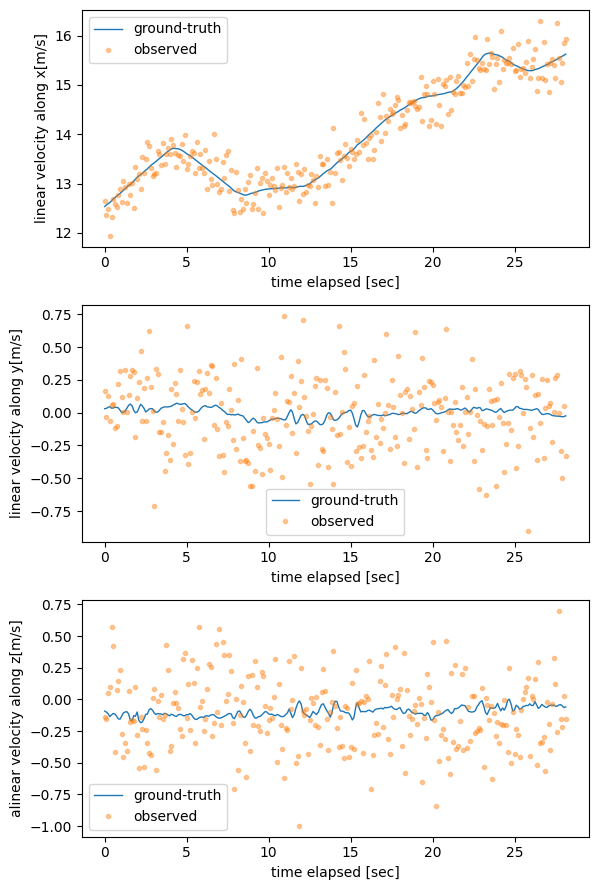

In [6]:
data.show_linear_velocity_with_noise()

# Applying filters

----

In [7]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS, VO+INS)'],
                                             ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']],
                                            names=['Setups','Filter types'])
df_dropout_indices = ['No dropout', '10% drop', '20% drop', '30% drop', '40% drop']

def get_error_dataframe(error_0, error_10, error_20, error_30, error_40):
    mae_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAE)
    mae_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAE)
    mae_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAE)
    mae_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAE)
    mae_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAE)

    rmse_0 = get_error_from_list(error_0, e_type=ErrorEnum.RMSE)
    rmse_10 = get_error_from_list(error_10, e_type=ErrorEnum.RMSE)
    rmse_20 = get_error_from_list(error_20, e_type=ErrorEnum.RMSE)
    rmse_30 = get_error_from_list(error_30, e_type=ErrorEnum.RMSE)
    rmse_40 = get_error_from_list(error_40, e_type=ErrorEnum.RMSE)
    
    max_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAX)
    max_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAX)
    max_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAX)
    max_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAX)
    max_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAX)
    
    mae_error = [mae_0, mae_10, mae_20, mae_30, mae_40]
    rmse_error = [rmse_0, rmse_10, rmse_20, rmse_30, rmse_40]
    max_error = [max_0, max_10, max_20, max_30, max_40]
    
    mae_df = pd.DataFrame(np.array(mae_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    rmse_df = pd.DataFrame(np.array(rmse_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    max_df = pd.DataFrame(np.array(max_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    
    return mae_df, rmse_df, max_df



In [8]:
errors_0 = []
errors_10 = []
errors_20 = []
errors_30 = []
errors_40 = []

# No measurement data drop

In [9]:
data.change_dropout_ratio(vo_dropout_ratio=0.0, gps_dropout_ratio=0.0)

In [10]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 6.0
kappa_setup1_0 = -7.0

alpha_setup2_0 = 0.0001
beta_setup2_0 = 0.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.0001
beta_setup3_0 = 0.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 64
resampling_algorithm_setup1_0 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_0 = 128
resampling_algorithm_setup2_0 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_0 = 128
resampling_algorithm_setup3_0 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_0 = 32
n_ensemble_setup2_0 = 128
n_ensemble_setup3_0 = 64

## Setup1

In [11]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [12]:
error_ekf1_0 = ekf1_0.run(data=data, debug_mode=True)
error_ukf1_0 = ukf1_0.run(data=data, debug_mode=True)
error_pf1_0 = pf1_0.run(data=data, debug_mode=True)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True)


errors_0.append(error_ekf1_0)
errors_0.append(error_ukf1_0)
errors_0.append(error_pf1_0)
errors_0.append(error_enkf1_0)
errors_0.append(error_ckf1_0)

[EKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 4230.06it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.684, <ErrorEnum.RMSE: 2>: 0.916, <ErrorEnum.MAX: 3>: 3.906}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1780.16it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.906, <ErrorEnum.RMSE: 2>: 1.128, <ErrorEnum.MAX: 3>: 3.478}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 914.964, <ErrorEnum.RMSE: 2>: 1602.06, <ErrorEnum.MAX: 3>: 5517.477}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2232.31it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.131, <ErrorEnum.RMSE: 2>: 1.417, <ErrorEnum.MAX: 3>: 4.707}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2878.62it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.91, <ErrorEnum.RMSE: 2>: 1.131, <ErrorEnum.MAX: 3>: 3.478}


## Setup2

In [13]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_0 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [14]:
error_ekf2_0 = ekf2_0.run(data=data, debug_mode=True)
error_ukf2_0 = ukf2_0.run(data=data, debug_mode=True)
error_pf2_0 = pf2_0.run(data=data, debug_mode=True)
error_enkf2_0 = enkf2_0.run(data=data, debug_mode=True)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf2_0)
errors_0.append(error_ukf2_0)
errors_0.append(error_pf2_0)
errors_0.append(error_enkf2_0)
errors_0.append(error_ckf2_0)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 10212.94it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.446, <ErrorEnum.RMSE: 2>: 0.599, <ErrorEnum.MAX: 3>: 3.08}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1875.60it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.568, <ErrorEnum.RMSE: 2>: 0.72, <ErrorEnum.MAX: 3>: 2.647}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 468.013, <ErrorEnum.RMSE: 2>: 910.29, <ErrorEnum.MAX: 3>: 3027.502}
[EnKF] start.


100%|████████████████████████████████████████| 270/270 [00:00<00:00, 581.71it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.952, <ErrorEnum.RMSE: 2>: 1.21, <ErrorEnum.MAX: 3>: 3.689}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2324.78it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.572, <ErrorEnum.RMSE: 2>: 0.725, <ErrorEnum.MAX: 3>: 2.646}


## Setup3

In [15]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_0 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_0 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_0, 
  beta=beta_setup3_0, 
  kappa=kappa_setup3_0,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_0 = ParticleFilter(
  N=n_samples_setup3_0, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_0
)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_0, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_0 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [16]:
error_ekf3_0 = ekf3_0.run(data=data, debug_mode=True)
error_ukf3_0 = ukf3_0.run(data=data, debug_mode=True)
error_pf3_0 = pf3_0.run(data=data, debug_mode=True)
error_enkf3_0 = enkf3_0.run(data=data, debug_mode=True)
error_ckf3_0 = ckf3_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf3_0)
errors_0.append(error_ukf3_0)
errors_0.append(error_pf3_0)
errors_0.append(error_enkf3_0)
errors_0.append(error_ckf3_0)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 17189.51it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.281, <ErrorEnum.RMSE: 2>: 0.336, <ErrorEnum.MAX: 3>: 0.911}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 5770.68it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.331, <ErrorEnum.RMSE: 2>: 0.413, <ErrorEnum.MAX: 3>: 1.246}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.291, <ErrorEnum.RMSE: 2>: 0.373, <ErrorEnum.MAX: 3>: 1.418}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1418.93it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.783, <ErrorEnum.RMSE: 2>: 0.997, <ErrorEnum.MAX: 3>: 2.83}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 6257.66it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.331, <ErrorEnum.RMSE: 2>: 0.413, <ErrorEnum.MAX: 3>: 1.246}


# 10% drop

In [17]:
data.change_dropout_ratio(vo_dropout_ratio=0.1, gps_dropout_ratio=0.1)

In [18]:
alpha_setup1_10 = 0.0001
beta_setup1_10 = 0.0
kappa_setup1_10 = -7.0

alpha_setup2_10 = 0.0001
beta_setup2_10 = 4.0
kappa_setup2_10 = -7.0

alpha_setup3_10 = 0.0001
beta_setup3_10 = 0.0
kappa_setup3_10 = 0.0

n_samples_setup1_10 = 128
resampling_algorithm_setup1_10 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_10 = 128
resampling_algorithm_setup2_10 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_10 = 256
resampling_algorithm_setup3_10 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_10 = 32
n_ensemble_setup2_10 = 128
n_ensemble_setup3_10 = 64

## Setup1

In [19]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_10 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_10 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_10, 
  beta=beta_setup1_10, 
  kappa=kappa_setup1_10,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_10 = ParticleFilter(
  N=n_samples_setup1_10, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_10
)
pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_10, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [20]:
error_ekf1_10 = ekf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_10 = ukf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_10 = pf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_10 = enkf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_10 = ckf1_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_10.append(error_ekf1_10)
errors_10.append(error_ukf1_10)
errors_10.append(error_pf1_10)
errors_10.append(error_enkf1_10)
errors_10.append(error_ckf1_10)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 12852.68it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.703, <ErrorEnum.RMSE: 2>: 0.947, <ErrorEnum.MAX: 3>: 4.858}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3177.32it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.996, <ErrorEnum.RMSE: 2>: 1.256, <ErrorEnum.MAX: 3>: 4.144}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.796, <ErrorEnum.RMSE: 2>: 1.024, <ErrorEnum.MAX: 3>: 3.48}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2795.24it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.272, <ErrorEnum.RMSE: 2>: 1.545, <ErrorEnum.MAX: 3>: 5.169}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3394.34it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.979, <ErrorEnum.RMSE: 2>: 1.244, <ErrorEnum.MAX: 3>: 4.139}


## Setup2

In [21]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_10 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_10, 
    beta=beta_setup2_10, 
    kappa=kappa_setup2_10,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_10 = ParticleFilter(
  N=n_samples_setup2_10, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_10
)
pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_10, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_10 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [22]:
error_ekf2_10 = ekf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_10 = ukf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_10 = pf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_10 = enkf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_10 = ckf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_10.append(error_ekf2_10)
errors_10.append(error_ukf2_10)
errors_10.append(error_pf2_10)
errors_10.append(error_enkf2_10)
errors_10.append(error_ckf2_10)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 10491.59it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.469, <ErrorEnum.RMSE: 2>: 0.636, <ErrorEnum.MAX: 3>: 3.267}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2352.39it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.611, <ErrorEnum.RMSE: 2>: 0.776, <ErrorEnum.MAX: 3>: 2.942}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.689, <ErrorEnum.RMSE: 2>: 0.862, <ErrorEnum.MAX: 3>: 2.548}
[EnKF] start.


100%|████████████████████████████████████████| 270/270 [00:00<00:00, 606.46it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.991, <ErrorEnum.RMSE: 2>: 1.265, <ErrorEnum.MAX: 3>: 4.209}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2507.66it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.62, <ErrorEnum.RMSE: 2>: 0.787, <ErrorEnum.MAX: 3>: 2.942}


## Setup3

In [23]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_10 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_10 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_10, 
  beta=beta_setup3_10, 
  kappa=kappa_setup3_10,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_10 = ParticleFilter(
  N=n_samples_setup3_10, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_10
)
pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_10, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_10 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [24]:
error_ekf3_10 = ekf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_10 = ukf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_10 = pf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_10 = enkf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_10 = ckf3_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_10.append(error_ekf3_10)
errors_10.append(error_ukf3_10)
errors_10.append(error_pf3_10)
errors_10.append(error_enkf3_10)
errors_10.append(error_ckf3_10)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 17926.93it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.284, <ErrorEnum.RMSE: 2>: 0.349, <ErrorEnum.MAX: 3>: 0.982}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 5955.31it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.345, <ErrorEnum.RMSE: 2>: 0.437, <ErrorEnum.MAX: 3>: 1.345}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.314, <ErrorEnum.RMSE: 2>: 0.404, <ErrorEnum.MAX: 3>: 1.606}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1589.76it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.803, <ErrorEnum.RMSE: 2>: 1.015, <ErrorEnum.MAX: 3>: 2.959}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 6688.61it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.345, <ErrorEnum.RMSE: 2>: 0.437, <ErrorEnum.MAX: 3>: 1.344}


# 20% drop

In [25]:
data.change_dropout_ratio(vo_dropout_ratio=0.2, gps_dropout_ratio=0.2)

In [26]:
alpha_setup1_20 = 0.0001
beta_setup1_20 = 10.0
kappa_setup1_20 = 0.0

alpha_setup2_20 = 0.0001
beta_setup2_20 = 2.0
kappa_setup2_20 = -7.0

alpha_setup3_20 = 0.0001
beta_setup3_20 = 0.0
kappa_setup3_20 = 0.0

n_samples_setup1_20 = 128
resampling_algorithm_setup1_20 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup2_20 = 128
resampling_algorithm_setup2_20 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup3_20 = 256
resampling_algorithm_setup3_20 = ResamplingAlgorithms.SYSTEMATIC

n_ensemble_setup1_20 = 32
n_ensemble_setup2_20 = 64
n_ensemble_setup3_20 = 128

## Setup1

In [27]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_20 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_20 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_20, 
  beta=beta_setup1_20, 
  kappa=kappa_setup1_20,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_20 = ParticleFilter(
  N=n_samples_setup1_20, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_20
)
pf1_20.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_20, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_20 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [28]:
error_ekf1_20 = ekf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_20 = ukf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_20 = pf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_20 = enkf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_20 = ckf1_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_20.append(error_ekf1_20)
errors_20.append(error_ukf1_20)
errors_20.append(error_pf1_20)
errors_20.append(error_enkf1_20)
errors_20.append(error_ckf1_20)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 12987.70it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.722, <ErrorEnum.RMSE: 2>: 0.97, <ErrorEnum.MAX: 3>: 4.525}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3284.19it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.042, <ErrorEnum.RMSE: 2>: 1.308, <ErrorEnum.MAX: 3>: 4.144}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.832, <ErrorEnum.RMSE: 2>: 1.055, <ErrorEnum.MAX: 3>: 3.285}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2893.52it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.24, <ErrorEnum.RMSE: 2>: 1.527, <ErrorEnum.MAX: 3>: 4.808}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3588.85it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.058, <ErrorEnum.RMSE: 2>: 1.346, <ErrorEnum.MAX: 3>: 4.134}


## Setup2

In [29]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_20 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_20 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_20, 
    beta=beta_setup2_20, 
    kappa=kappa_setup2_20,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_20 = ParticleFilter(
  N=n_samples_setup2_20, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_20
)
pf2_20.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_20, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_20 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [30]:
error_ekf2_20 = ekf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_20 = ukf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_20 = pf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_20 = enkf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_20 = ckf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_20.append(error_ekf2_20)
errors_20.append(error_ukf2_20)
errors_20.append(error_pf2_20)
errors_20.append(error_enkf2_20)
errors_20.append(error_ckf2_20)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 11176.86it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.471, <ErrorEnum.RMSE: 2>: 0.627, <ErrorEnum.MAX: 3>: 3.08}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2078.53it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.585, <ErrorEnum.RMSE: 2>: 0.742, <ErrorEnum.MAX: 3>: 2.473}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.681, <ErrorEnum.RMSE: 2>: 0.865, <ErrorEnum.MAX: 3>: 3.557}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1219.88it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.001, <ErrorEnum.RMSE: 2>: 1.276, <ErrorEnum.MAX: 3>: 4.083}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2502.27it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.594, <ErrorEnum.RMSE: 2>: 0.755, <ErrorEnum.MAX: 3>: 2.473}


## Setup3

In [31]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_20 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_20 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_20, 
  beta=beta_setup3_20, 
  kappa=kappa_setup3_20,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_20 = ParticleFilter(
  N=n_samples_setup3_20, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_20
)
pf3_20.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_20, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_20 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [32]:
error_ekf3_20 = ekf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_20 = ukf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_20 = pf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_20 = enkf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_20 = ckf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_20.append(error_ekf3_20)
errors_20.append(error_ukf3_20)
errors_20.append(error_pf3_20)
errors_20.append(error_enkf3_20)
errors_20.append(error_ckf3_20)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 19824.98it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.263, <ErrorEnum.RMSE: 2>: 0.333, <ErrorEnum.MAX: 3>: 0.972}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 6661.07it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.333, <ErrorEnum.RMSE: 2>: 0.417, <ErrorEnum.MAX: 3>: 1.288}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.302, <ErrorEnum.RMSE: 2>: 0.397, <ErrorEnum.MAX: 3>: 1.379}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1023.82it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.757, <ErrorEnum.RMSE: 2>: 0.976, <ErrorEnum.MAX: 3>: 2.709}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 6957.31it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.333, <ErrorEnum.RMSE: 2>: 0.417, <ErrorEnum.MAX: 3>: 1.291}


# 30% drop

In [33]:
data.change_dropout_ratio(vo_dropout_ratio=0.3, gps_dropout_ratio=0.3)

In [34]:
alpha_setup1_30 = 0.001
beta_setup1_30 = 0.0
kappa_setup1_30 = -7.0

alpha_setup2_30 = 0.0001
beta_setup2_30 = 8.0
kappa_setup2_30 = 0.0

alpha_setup3_30 = 0.0001
beta_setup3_30 = 0.0
kappa_setup3_30 = 0.0

n_samples_setup1_30 = 128
resampling_algorithm_setup1_30 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_30 = 128
resampling_algorithm_setup2_30 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_30 = 512
resampling_algorithm_setup3_30 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_30 = 64
n_ensemble_setup2_30 = 128
n_ensemble_setup3_30 = 32

## Setup1

In [35]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_30 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_30 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_30, 
  beta=beta_setup1_30, 
  kappa=kappa_setup1_30,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_30 = ParticleFilter(
  N=n_samples_setup1_30, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_30
)
pf1_30.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_30, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_30 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 13243.78it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.783, <ErrorEnum.RMSE: 2>: 1.047, <ErrorEnum.MAX: 3>: 4.56}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3297.50it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.163, <ErrorEnum.RMSE: 2>: 1.479, <ErrorEnum.MAX: 3>: 5.737}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.873, <ErrorEnum.RMSE: 2>: 1.129, <ErrorEnum.MAX: 3>: 4.287}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1870.80it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.27, <ErrorEnum.RMSE: 2>: 1.584, <ErrorEnum.MAX: 3>: 5.363}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3285.43it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 0.91, <ErrorEnum.RMSE: 2>: 1.131, <ErrorEnum.MAX: 3>: 3.478}


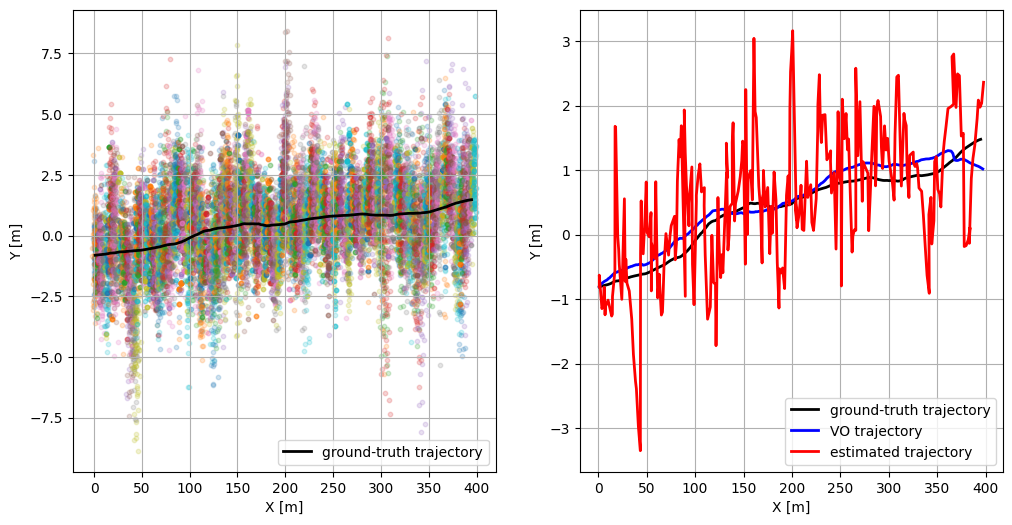

In [36]:
error_ekf1_30 = ekf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_30 = ukf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_30 = pf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True,
    show_graph=True
)
error_enkf1_30 = enkf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_30 = ckf1_30.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf1_30)
errors_30.append(error_ukf1_30)
errors_30.append(error_pf1_30)
errors_30.append(error_enkf1_30)
errors_30.append(error_ckf1_30)

## Setup2

In [37]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_30 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_30 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_30, 
    beta=beta_setup2_30, 
    kappa=kappa_setup2_30,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_30 = ParticleFilter(
  N=n_samples_setup2_30, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_30
)
pf2_30.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_30, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_30 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [38]:
error_ekf2_30 = ekf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_30 = ukf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_30 = pf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_30 = enkf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_30 = ckf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf2_30)
errors_30.append(error_ukf2_30)
errors_30.append(error_pf2_30)
errors_30.append(error_enkf2_30)
errors_30.append(error_ckf2_30)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 12955.01it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.783, <ErrorEnum.RMSE: 2>: 1.047, <ErrorEnum.MAX: 3>: 4.56}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2618.59it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.649, <ErrorEnum.RMSE: 2>: 0.83, <ErrorEnum.MAX: 3>: 3.005}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 39.566, <ErrorEnum.RMSE: 2>: 104.206, <ErrorEnum.MAX: 3>: 553.437}
[EnKF] start.


100%|████████████████████████████████████████| 270/270 [00:00<00:00, 730.87it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.014, <ErrorEnum.RMSE: 2>: 1.284, <ErrorEnum.MAX: 3>: 4.137}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2806.68it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.649, <ErrorEnum.RMSE: 2>: 0.838, <ErrorEnum.MAX: 3>: 3.005}


## Setup3

In [39]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_30 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_30 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_30, 
  beta=beta_setup3_30, 
  kappa=kappa_setup3_30,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_30 = ParticleFilter(
  N=n_samples_setup3_30, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_30
)
pf3_30.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_30, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_30 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [40]:
error_ekf3_30 = ekf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_30 = ukf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_30 = pf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_30 = enkf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_30 = ckf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)


errors_30.append(error_ekf3_30)
errors_30.append(error_ukf3_30)
errors_30.append(error_pf3_30)
errors_30.append(error_enkf3_30)
errors_30.append(error_ckf3_30)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 20735.75it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.294, <ErrorEnum.RMSE: 2>: 0.352, <ErrorEnum.MAX: 3>: 0.942}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 7381.69it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.345, <ErrorEnum.RMSE: 2>: 0.433, <ErrorEnum.MAX: 3>: 1.337}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.325, <ErrorEnum.RMSE: 2>: 0.432, <ErrorEnum.MAX: 3>: 1.655}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3167.97it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.845, <ErrorEnum.RMSE: 2>: 1.076, <ErrorEnum.MAX: 3>: 3.836}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 7924.19it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.345, <ErrorEnum.RMSE: 2>: 0.434, <ErrorEnum.MAX: 3>: 1.342}


# 40% drop

In [41]:
data.change_dropout_ratio(vo_dropout_ratio=0.4, gps_dropout_ratio=0.4)

In [42]:
alpha_setup1_40 = 1.0
beta_setup1_40 = 10.0
kappa_setup1_40 = -7.0

alpha_setup2_40 = 0.2
beta_setup2_40 = 8.0
kappa_setup2_40 = 0.0

alpha_setup3_40 = 0.0001
beta_setup3_40 = 2.0
kappa_setup3_40 = 0.0

n_samples_setup1_40 = 128
resampling_algorithm_setup1_40 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_40 = 128
resampling_algorithm_setup2_40 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_40 = 512
resampling_algorithm_setup3_40 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_40 = 64
n_ensemble_setup2_40 = 64
n_ensemble_setup3_40 = 32

## Setup1

In [43]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_40 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_40 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_40, 
  beta=beta_setup1_40, 
  kappa=kappa_setup1_40,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_40 = ParticleFilter(
  N=n_samples_setup1_40, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_40
)
pf1_40.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_40, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_40 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [44]:
error_ekf1_40 = ekf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_40 = ukf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_40 = pf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_40 = enkf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_40 = ckf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_40.append(error_ekf1_40)
errors_40.append(error_ukf1_40)
errors_40.append(error_pf1_40)
errors_40.append(error_enkf1_40)
errors_40.append(error_ckf1_40)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 13578.68it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.846, <ErrorEnum.RMSE: 2>: 1.194, <ErrorEnum.MAX: 3>: 7.764}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3708.43it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.349, <ErrorEnum.RMSE: 2>: 1.824, <ErrorEnum.MAX: 3>: 6.473}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 733.868, <ErrorEnum.RMSE: 2>: 1129.342, <ErrorEnum.MAX: 3>: 3074.809}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1991.88it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.233, <ErrorEnum.RMSE: 2>: 1.581, <ErrorEnum.MAX: 3>: 7.056}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 4055.59it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.393, <ErrorEnum.RMSE: 2>: 1.869, <ErrorEnum.MAX: 3>: 6.638}


## Setup2

In [45]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_40 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_40 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_40, 
    beta=beta_setup2_40, 
    kappa=kappa_setup2_40,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_40 = ParticleFilter(
  N=n_samples_setup2_40, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_40
)
pf2_40.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_40, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_40 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [46]:
error_ekf2_40 = ekf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_40 = ukf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_40 = pf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_40 = enkf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_40 = ckf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf2_40)
errors_40.append(error_ukf2_40)
errors_40.append(error_pf2_40)
errors_40.append(error_enkf2_40)
errors_40.append(error_ckf2_40)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 12102.70it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.534, <ErrorEnum.RMSE: 2>: 0.768, <ErrorEnum.MAX: 3>: 4.34}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2842.55it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.71, <ErrorEnum.RMSE: 2>: 0.923, <ErrorEnum.MAX: 3>: 4.129}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 54.681, <ErrorEnum.RMSE: 2>: 119.254, <ErrorEnum.MAX: 3>: 577.653}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1445.99it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.102, <ErrorEnum.RMSE: 2>: 1.4, <ErrorEnum.MAX: 3>: 5.165}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3114.15it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.722, <ErrorEnum.RMSE: 2>: 0.934, <ErrorEnum.MAX: 3>: 4.129}


## Setup3

In [47]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_40 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_40 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_40, 
  beta=beta_setup3_40, 
  kappa=kappa_setup3_40,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_40 = ParticleFilter(
  N=n_samples_setup3_40, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_40
)
pf3_40.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_40, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_40 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [48]:
error_ekf3_40 = ekf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_40 = ukf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_40 = pf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_40 = enkf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_40 = ckf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf3_40)
errors_40.append(error_ukf3_40)
errors_40.append(error_pf3_40)
errors_40.append(error_enkf3_40)
errors_40.append(error_ckf3_40)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 21832.28it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.288, <ErrorEnum.RMSE: 2>: 0.352, <ErrorEnum.MAX: 3>: 1.226}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 7135.51it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.358, <ErrorEnum.RMSE: 2>: 0.45, <ErrorEnum.MAX: 3>: 1.339}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.375, <ErrorEnum.RMSE: 2>: 0.494, <ErrorEnum.MAX: 3>: 2.0}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3508.82it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.862, <ErrorEnum.RMSE: 2>: 1.097, <ErrorEnum.MAX: 3>: 3.633}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 8381.72it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.358, <ErrorEnum.RMSE: 2>: 0.451, <ErrorEnum.MAX: 3>: 1.343}


# Results

In [49]:
mae_df, rmse_df, max_df = get_error_dataframe(errors_0, errors_10, errors_20, errors_30, errors_40)

In [50]:
mae_df

Setups       Setup1 (IMU, VO)                                \
Filter types              EKF    UKF       PF   EnKF    CKF   
No dropout              0.684  0.906  914.964  1.131  0.910   
10% drop                0.703  0.996    0.796  1.272  0.979   
20% drop                0.722  1.042    0.832  1.240  1.058   
30% drop                0.783  1.163    0.873  1.270  0.910   
40% drop                0.846  1.349  733.868  1.233  1.393   

Setups       Setup2(IMU, VO+GPS)                                \
Filter types                 EKF    UKF       PF   EnKF    CKF   
No dropout                 0.446  0.568  468.013  0.952  0.572   
10% drop                   0.469  0.611    0.689  0.991  0.620   
20% drop                   0.471  0.585    0.681  1.001  0.594   
30% drop                   0.783  0.649   39.566  1.014  0.649   
40% drop                   0.534  0.710   54.681  1.102  0.722   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 0.281  0.331  0.291  0.783  0.331  
10% drop                   0.284  0.345  0.314  0.803  0.345  
20% drop                   0.263  0.333  0.302  0.757  0.333  
30% drop                   0.294  0.345  0.325  0.845  0.345  
40% drop                   0.288  0.358  0.375  0.862  0.358

In [51]:
rmse_df

Setups       Setup1 (IMU, VO)                                 \
Filter types              EKF    UKF        PF   EnKF    CKF   
No dropout              0.916  1.128  1602.060  1.417  1.131   
10% drop                0.947  1.256     1.024  1.545  1.244   
20% drop                0.970  1.308     1.055  1.527  1.346   
30% drop                1.047  1.479     1.129  1.584  1.131   
40% drop                1.194  1.824  1129.342  1.581  1.869   

Setups       Setup2(IMU, VO+GPS)                                \
Filter types                 EKF    UKF       PF   EnKF    CKF   
No dropout                 0.599  0.720  910.290  1.210  0.725   
10% drop                   0.636  0.776    0.862  1.265  0.787   
20% drop                   0.627  0.742    0.865  1.276  0.755   
30% drop                   1.047  0.830  104.206  1.284  0.838   
40% drop                   0.768  0.923  119.254  1.400  0.934   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 0.336  0.413  0.373  0.997  0.413  
10% drop                   0.349  0.437  0.404  1.015  0.437  
20% drop                   0.333  0.417  0.397  0.976  0.417  
30% drop                   0.352  0.433  0.432  1.076  0.434  
40% drop                   0.352  0.450  0.494  1.097  0.451

In [52]:
max_df

Setups       Setup1 (IMU, VO)                                 \
Filter types              EKF    UKF        PF   EnKF    CKF   
No dropout              3.906  3.478  5517.477  4.707  3.478   
10% drop                4.858  4.144     3.480  5.169  4.139   
20% drop                4.525  4.144     3.285  4.808  4.134   
30% drop                4.560  5.737     4.287  5.363  3.478   
40% drop                7.764  6.473  3074.809  7.056  6.638   

Setups       Setup2(IMU, VO+GPS)                                 \
Filter types                 EKF    UKF        PF   EnKF    CKF   
No dropout                 3.080  2.647  3027.502  3.689  2.646   
10% drop                   3.267  2.942     2.548  4.209  2.942   
20% drop                   3.080  2.473     3.557  4.083  2.473   
30% drop                   4.560  3.005   553.437  4.137  3.005   
40% drop                   4.340  4.129   577.653  5.165  4.129   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 0.911  1.246  1.418  2.830  1.246  
10% drop                   0.982  1.345  1.606  2.959  1.344  
20% drop                   0.972  1.288  1.379  2.709  1.291  
30% drop                   0.942  1.337  1.655  3.836  1.342  
40% drop                   1.226  1.339  2.000  3.633  1.343

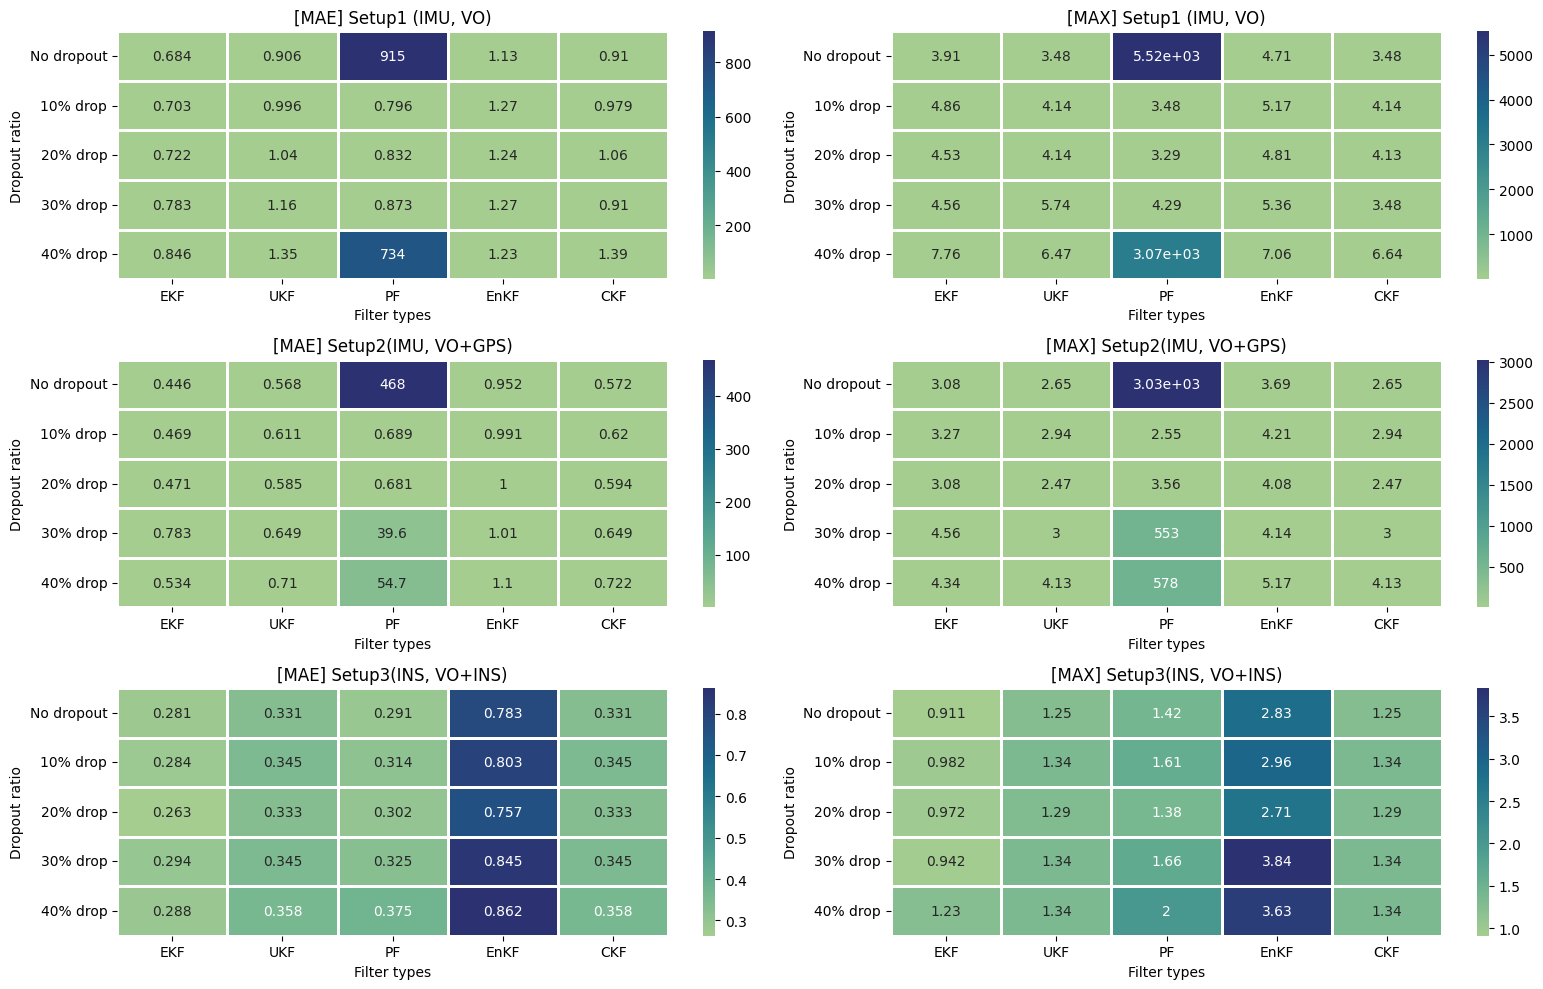

In [53]:
fig, (ax1_, ax2_, ax3_) = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
ax1, ax2 = ax1_[0], ax1_[1]
ax3, ax4 = ax2_[0], ax2_[1]
ax5, ax6 = ax3_[0], ax3_[1]

sns.heatmap(mae_df["Setup1 (IMU, VO)"],
            ax=ax1,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax1.set_title("[MAE] Setup1 (IMU, VO)")
ax1.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup2(IMU, VO+GPS)"],
            ax=ax3,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax3.set_title("[MAE] Setup2(IMU, VO+GPS)")
ax3.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup3(INS, VO+INS)"],
            ax=ax5,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax5.set_title("[MAE] Setup3(INS, VO+INS)")
ax5.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup1 (IMU, VO)"],
            ax=ax2,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax2.set_title("[MAX] Setup1 (IMU, VO)")
ax2.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup2(IMU, VO+GPS)"],
            ax=ax4,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax4.set_title("[MAX] Setup2(IMU, VO+GPS)")
ax4.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup3(INS, VO+INS)"],
            ax=ax6,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax6.set_title("[MAX] Setup3(INS, VO+INS)")
ax6.set(xlabel="Filter types", ylabel="Dropout ratio")

fig.tight_layout()

In [54]:
mae_df.to_json(os.path.join(file_export_path, "mae_df.json"))
rmse_df.to_json(os.path.join(file_export_path, "rmse_df.json"))
max_df.to_json(os.path.join(file_export_path, "max_df.json"))